In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
salary_df = pd.read_csv("data/salary_data.csv")
salary_df = salary_df.loc[:, ~salary_df.columns.str.startswith("Unnamed")]
print(salary_df.shape)
salary_df.info()
salary_df.describe(include="all")

(100, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Age             100 non-null    int64 
 1   City            100 non-null    object
 2   Education       100 non-null    object
 3   Job_Role        100 non-null    object
 4   Monthly_Salary  100 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 4.0+ KB


,Age,City,Education,Job_Role,Monthly_Salary
count,100.000000,100,100,100,100.000000
unique,NaN,10,8,10,NaN
top,NaN,Jaipur,MCA,DevOps Engineer,NaN
freq,NaN,20,21,18,NaN
mean,29.000000,NaN,NaN,NaN,58510.000000
std,5.146343,NaN,NaN,NaN,26356.336328
min,21.000000,NaN,NaN,NaN,18000.000000
25%,24.750000,NaN,NaN,NaN,35750.000000
50%,28.000000,NaN,NaN,NaN,53500.000000
75%,34.000000,NaN,NaN,NaN,78250.000000


In [3]:
print(salary_df.isna().sum())
print(f"duplicate rows: {salary_df.duplicated().sum()}")
salary_df = salary_df.drop_duplicates().reset_index(drop=True)

Age               0
City              0
Education         0
Job_Role          0
Monthly_Salary    0
dtype: int64
duplicate rows: 0


In [4]:
for col in ["City", "Education", "Job_Role"]:
    print(salary_df[col].value_counts())
    print()

City
Jaipur       20
Kolkata      14
Pune         12
Chennai      10
Ahmedabad    10
Mumbai        9
Hyderabad     8
Delhi         6
Lucknow       6
Bangalore     5
Name: count, dtype: int64

Education
MCA       21
MBA       13
B.E.      13
BCA       12
B.Sc      12
B.Tech    11
M.Sc       9
M.Tech     9
Name: count, dtype: int64

Job_Role
DevOps Engineer               18
Web Developer                 13
QA Engineer                   13
Project Coordinator           11
UI UX Designer                10
Technical Support Engineer     8
Software Engineer              8
Data Analyst                   7
Data Scientist                 7
Business Analyst               5
Name: count, dtype: int64



In [5]:
def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)]

print("Age outliers:", iqr_outliers(salary_df["Age"]).tolist())
print("Salary outliers:", iqr_outliers(salary_df["Monthly_Salary"]).tolist())
print("Salary skew:", salary_df["Monthly_Salary"].skew())

Age outliers: []
Salary outliers: []
Salary skew: 0.4305511369026093


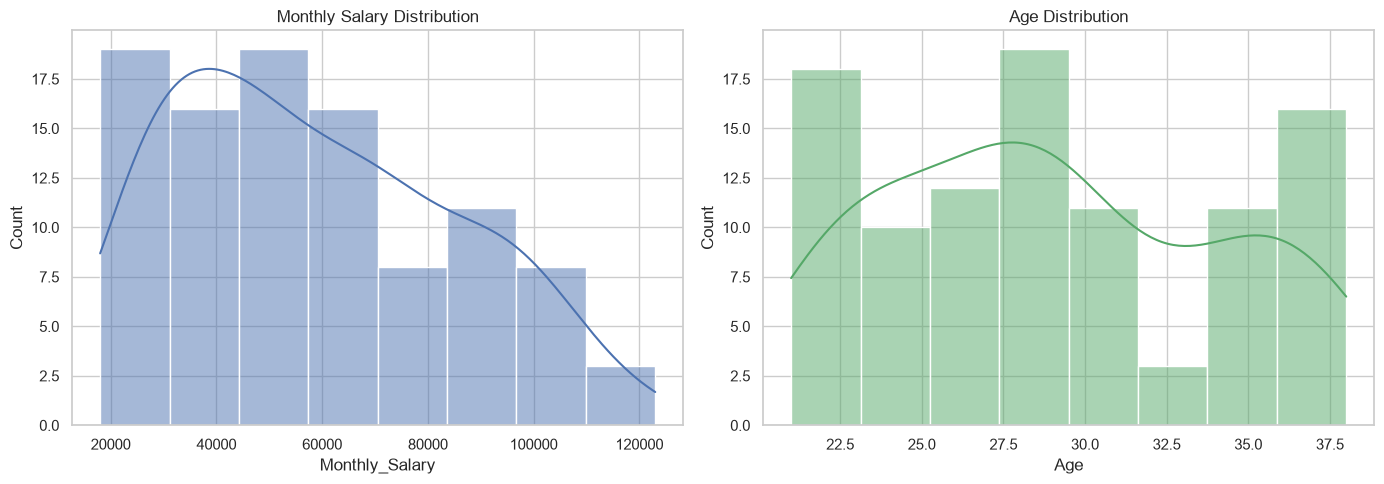

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(salary_df["Monthly_Salary"], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Monthly Salary Distribution")
sns.histplot(salary_df["Age"], kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Age Distribution")
plt.tight_layout()
plt.show()

C:\Users\dibya\AppData\Local\Temp\ipykernel_4284\4579803.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=salary_df, x=col, y="Monthly_Salary", order=order, ax=ax, palette="tab10")
C:\Users\dibya\AppData\Local\Temp\ipykernel_4284\4579803.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=salary_df, x=col, y="Monthly_Salary", order=order, ax=ax, palette="tab10")
C:\Users\dibya\AppData\Local\Temp\ipykernel_4284\4579803.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=salary_df, x=col, y="Monthly_Salary", order=order, ax=a

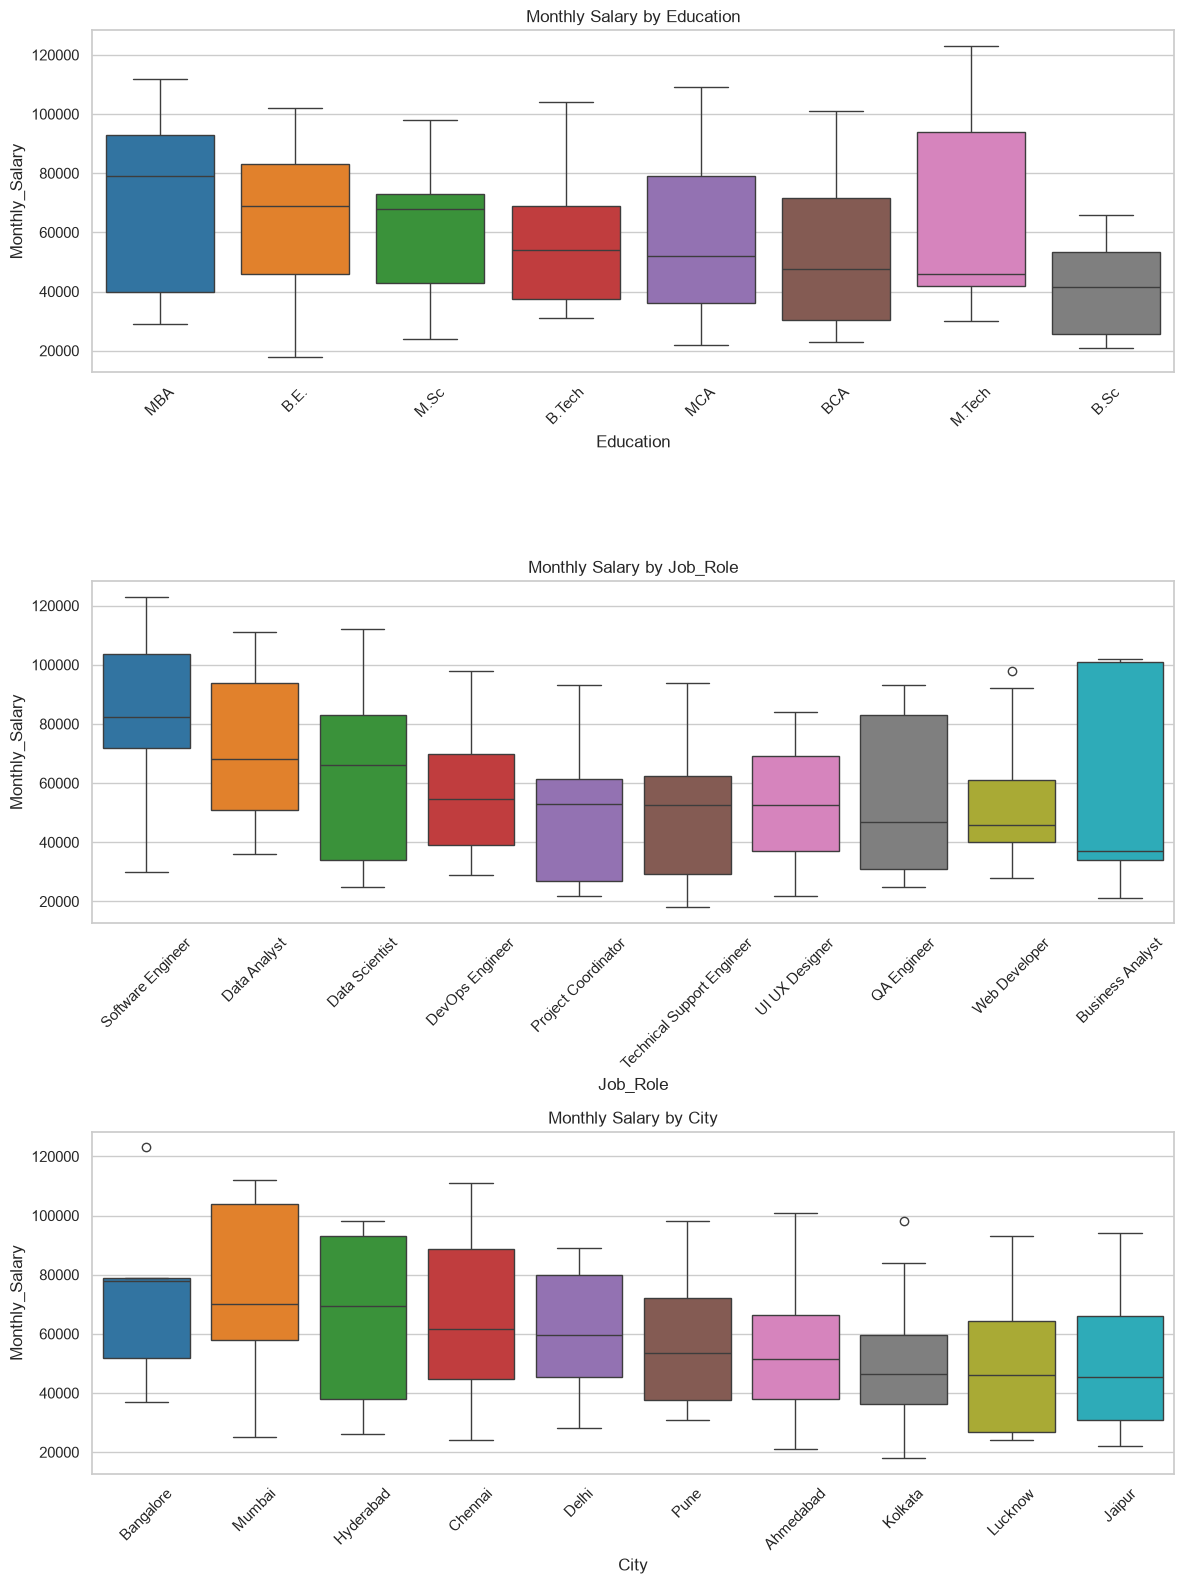

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 16))
for ax, col in zip(axes, ["Education", "Job_Role", "City"]):
    order = salary_df.groupby(col)["Monthly_Salary"].median().sort_values(ascending=False).index
    sns.boxplot(data=salary_df, x=col, y="Monthly_Salary", order=order, ax=ax, palette="tab10")
    ax.set_title(f"Monthly Salary by {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

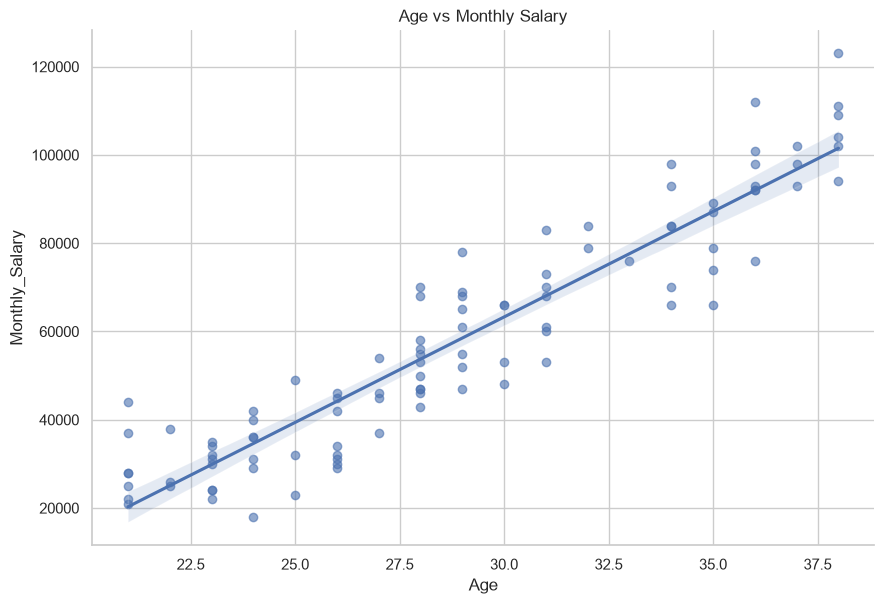

Pearson corr(Age, Salary): 0.9331828487134908


In [8]:
sns.lmplot(data=salary_df, x="Age", y="Monthly_Salary", height=6, aspect=1.5, scatter_kws={"alpha": 0.6})
plt.title("Age vs Monthly Salary")
plt.show()
print("Pearson corr(Age, Salary):", salary_df["Age"].corr(salary_df["Monthly_Salary"]))

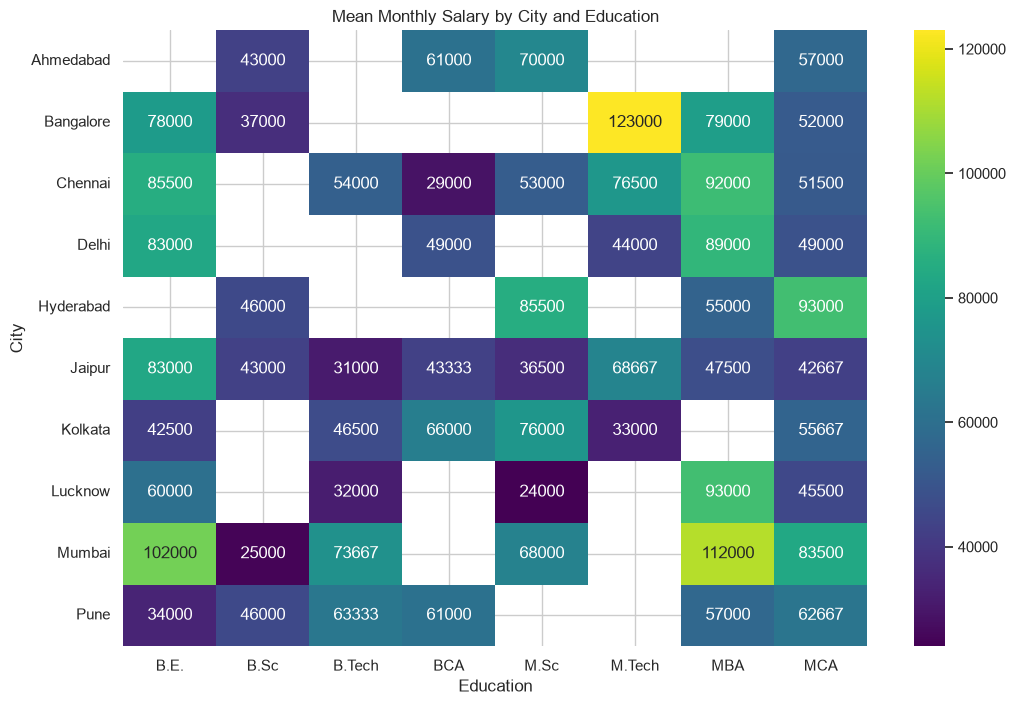

In [9]:
pivot = salary_df.pivot_table(index="City", columns="Education", values="Monthly_Salary", aggfunc="mean")
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis")
plt.title("Mean Monthly Salary by City and Education")
plt.show()

In [10]:
categorical_cols = ["City", "Education", "Job_Role"]
salary_encoded = pd.get_dummies(salary_df, columns=categorical_cols, drop_first=False)

X = salary_encoded.drop(columns=["Monthly_Salary"])
y = salary_encoded["Monthly_Salary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

salary_encoded.to_csv("data/salary_data_processed.csv", index=False)

(80, 29) (20, 29)


In [11]:
goal_df = pd.read_csv("data/city_goal_costs.csv")
print(goal_df.shape)
goal_df.info()
goal_df.describe()
print(goal_df.isna().sum())
print("duplicate rows:", goal_df.duplicated().sum())
print("duplicate City+Area_Type combos:", goal_df.duplicated(subset=["City", "Area_Type"]).sum())

(100, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   City                   100 non-null    object
 1   Area_Type              100 non-null    object
 2   Marriage_Cost_Current  100 non-null    int64 
 3   Car_Cost_Current       100 non-null    int64 
 4   Home_Cost_Current      100 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 4.0+ KB
City                     0
Area_Type                0
Marriage_Cost_Current    0
Car_Cost_Current         0
Home_Cost_Current        0
dtype: int64
duplicate rows: 0
duplicate City+Area_Type combos: 0


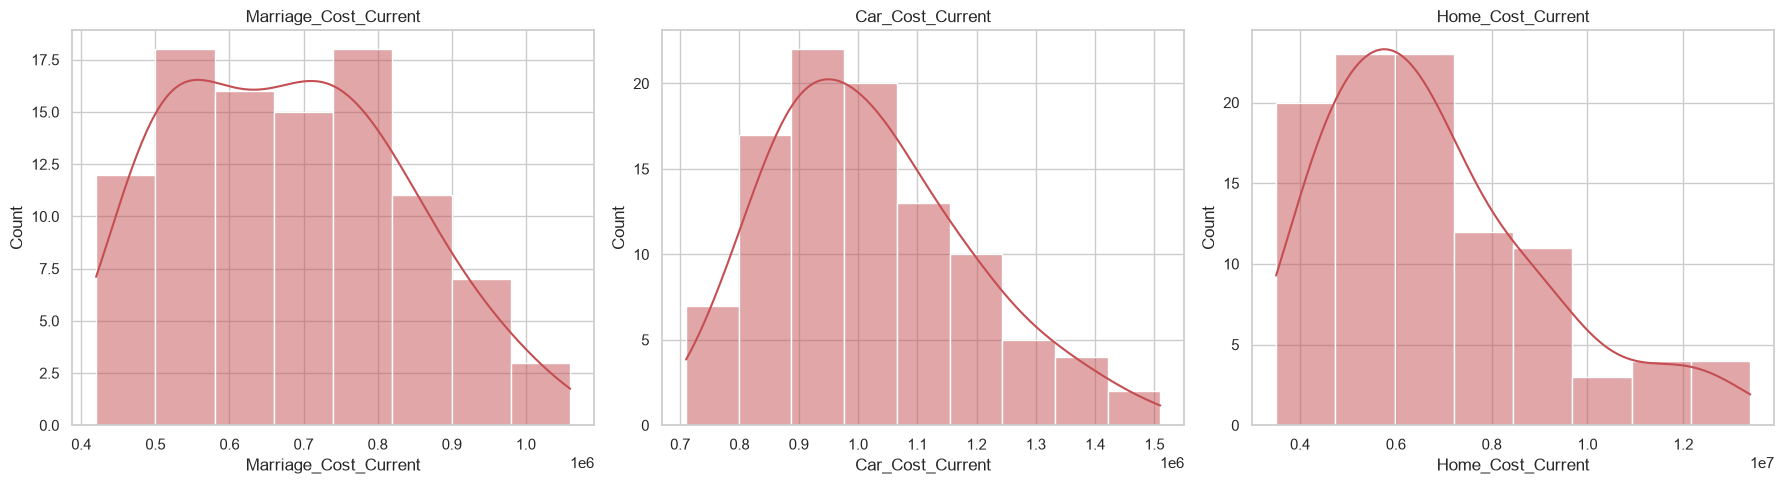

In [12]:
cost_cols = ["Marriage_Cost_Current", "Car_Cost_Current", "Home_Cost_Current"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cost_cols):
    sns.histplot(goal_df[col], kde=True, ax=ax, color="#C44E52")
    ax.set_title(col)
plt.tight_layout()
plt.show()

C:\Users\dibya\AppData\Local\Temp\ipykernel_4284\3036024400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=goal_df, x="Area_Type", y=col, order=order, ax=ax, palette="tab10")
C:\Users\dibya\AppData\Local\Temp\ipykernel_4284\3036024400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=goal_df, x="Area_Type", y=col, order=order, ax=ax, palette="tab10")
C:\Users\dibya\AppData\Local\Temp\ipykernel_4284\3036024400.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=goal_df, x="Area_Type", y=col, order=order, ax=ax, palette="

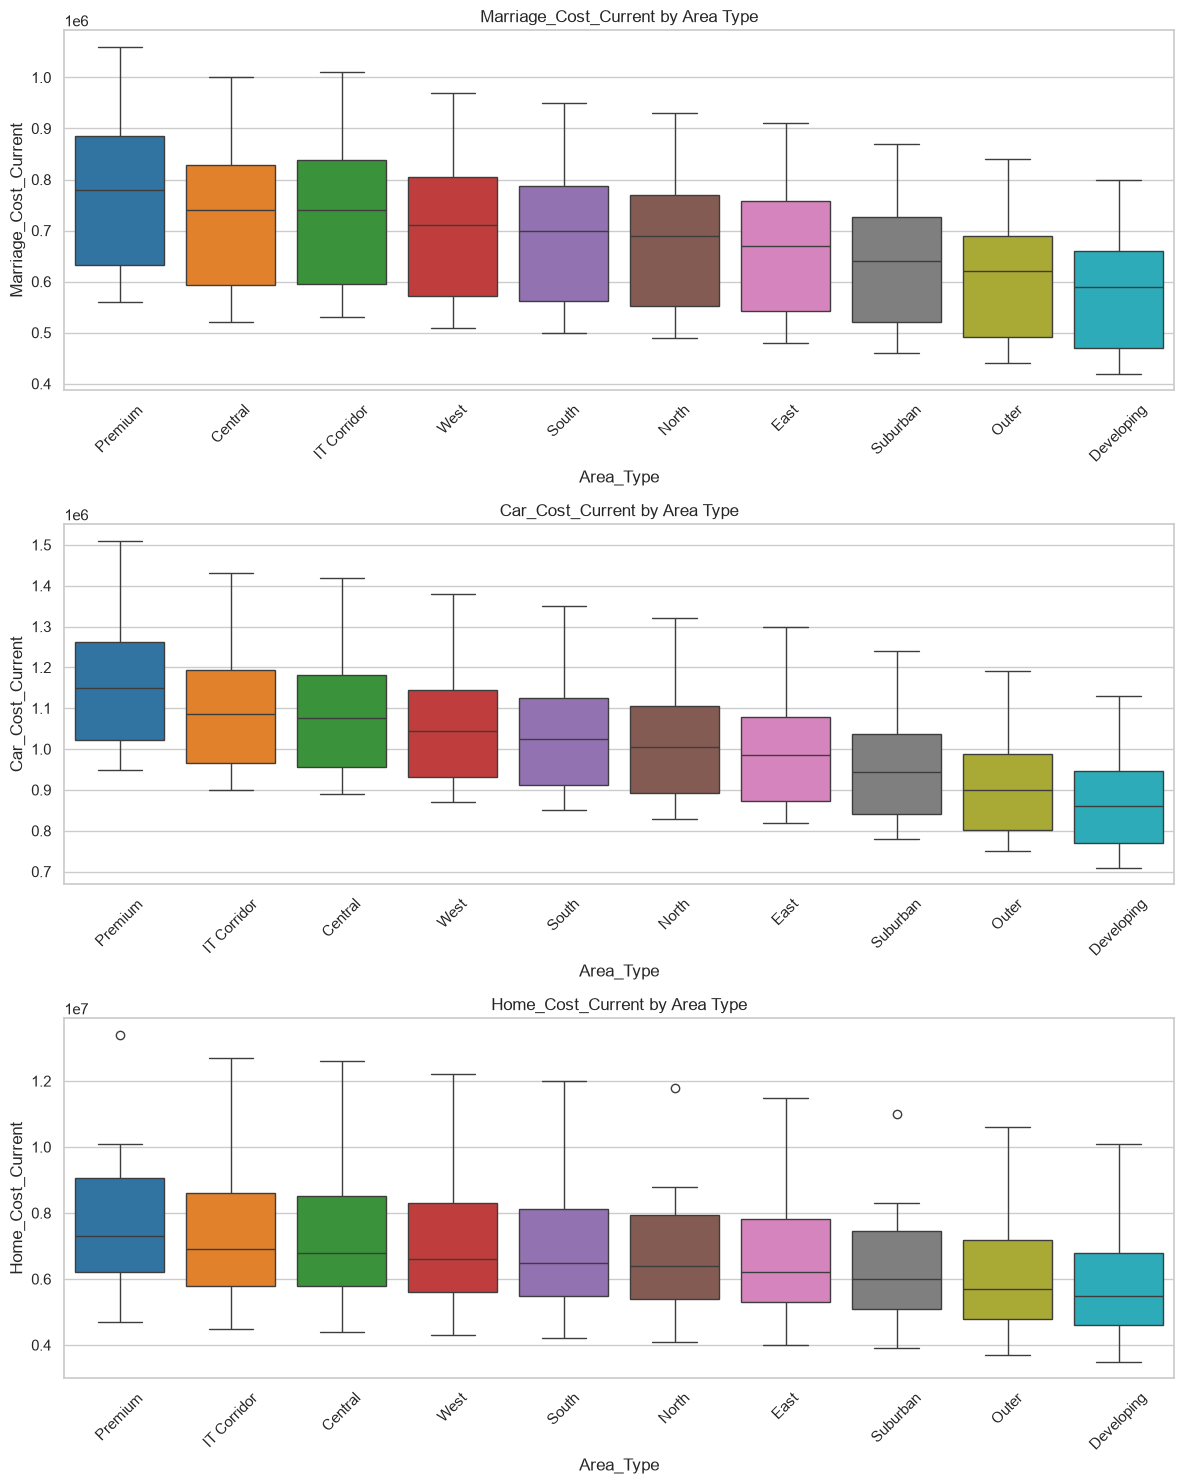

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))
for ax, col in zip(axes, cost_cols):
    order = goal_df.groupby("Area_Type")[col].median().sort_values(ascending=False).index
    sns.boxplot(data=goal_df, x="Area_Type", y=col, order=order, ax=ax, palette="tab10")
    ax.set_title(f"{col} by Area Type")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

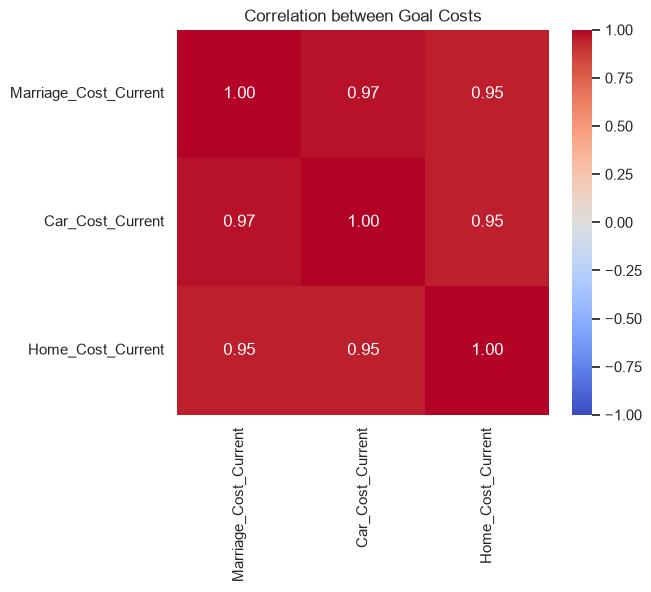

In [14]:
corr = goal_df[cost_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation between Goal Costs")
plt.show()

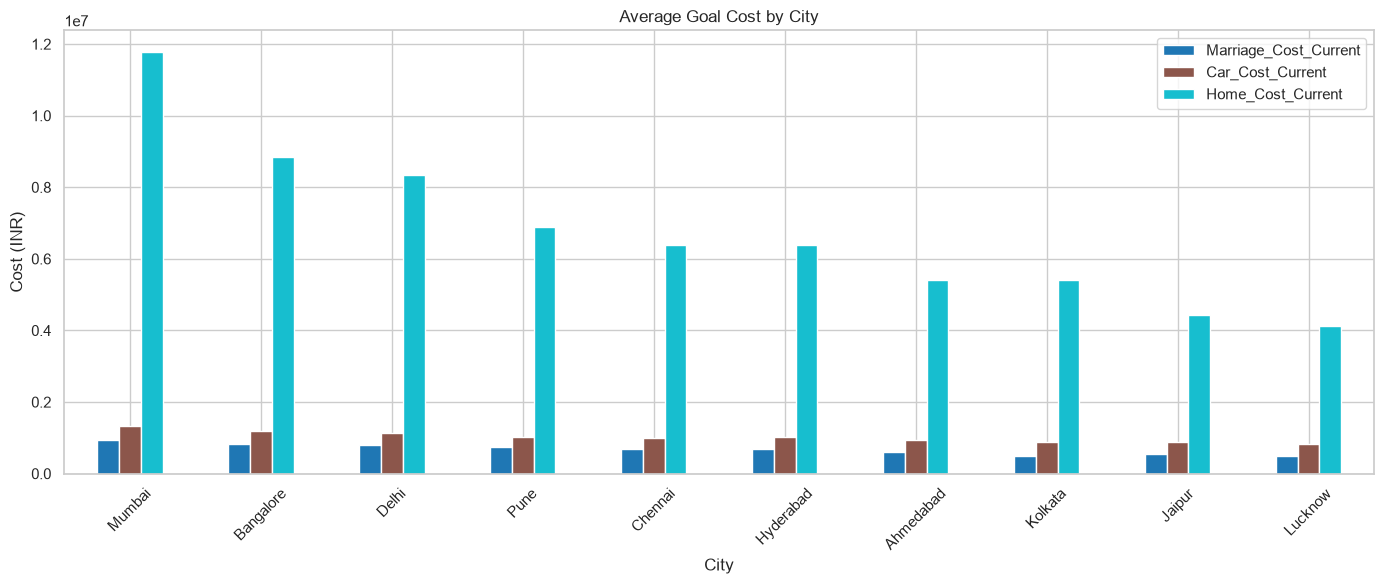

In [15]:
city_avg = goal_df.groupby("City")[cost_cols].mean().sort_values("Home_Cost_Current", ascending=False)
city_avg.plot(kind="bar", figsize=(14, 6), colormap="tab10")
plt.title("Average Goal Cost by City")
plt.ylabel("Cost (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

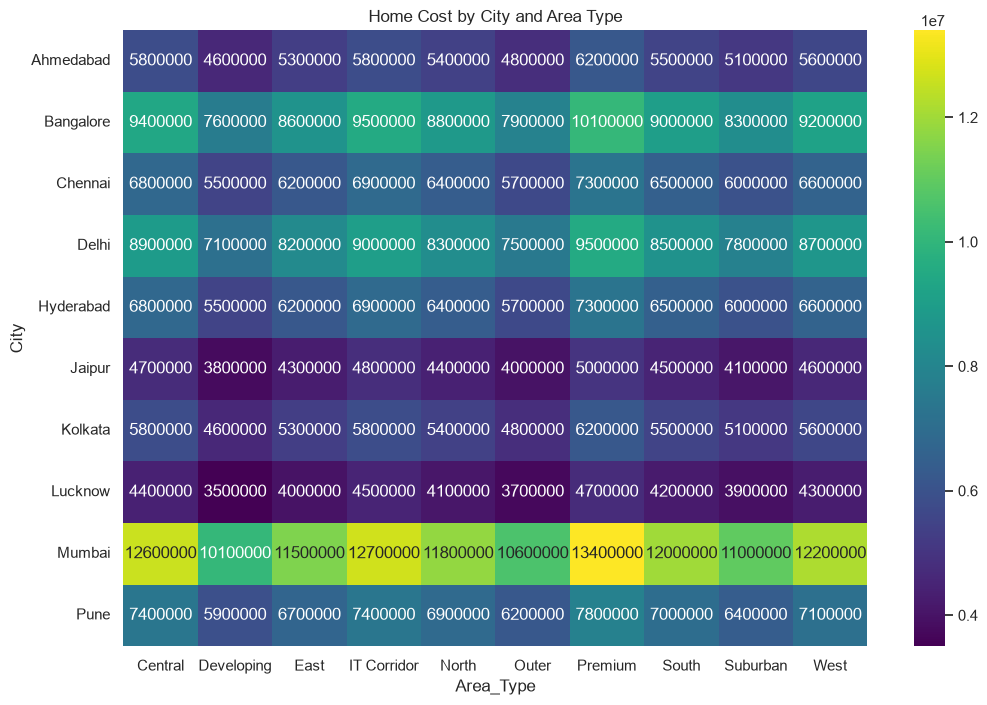

In [16]:
home_pivot = goal_df.pivot(index="City", columns="Area_Type", values="Home_Cost_Current")
plt.figure(figsize=(12, 8))
sns.heatmap(home_pivot, annot=True, fmt=".0f", cmap="viridis")
plt.title("Home Cost by City and Area Type")
plt.show()

In [17]:
goal_encoded = pd.get_dummies(goal_df, columns=["City", "Area_Type"], drop_first=False)
goal_encoded.to_csv("data/city_goal_costs_processed.csv", index=False)
print(goal_encoded.shape)

(100, 23)
